# 🎯 Ziel dieser Lektion: Aktivierungsfunktionen

**Was wollen wir erreichen?** 
Wir untersuchen verschiedene Aktivierungsfunktionen (wie Sigmoid, ReLU, Tanh) und verstehen, warum sie das wahre Geheimnis hinter der Intelligenz neuronaler Netze sind.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Ein Netzwerk, das bisher nur lineare (einfache, gerade) Berechnungen machen kann.
- **Endziel (Gesucht):** Die richtige Funktion auswählen, damit das Netzwerk auch sehr komplizierte, gebogene Muster in den Daten lernen kann, ohne dabei zu langsam zu werden.

### 🛤️ Ablauf (Schritt-für-Schritt)
`Funktion auswählen (z.B. ReLU)` ➔ `Mathematische Formel anwenden` ➔ `Ableitung (Gradient) berechnen` ➔ `Auswirkung auf das Lernen beobachten` ➔ `Beste Funktion für das Problem finden`


## Exercise 1

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `class Mish(tf.keras.layers.Layer):` | Definiert eine Klasse. Dies ist der Bauplan für ein Objekt in der objektorientierten Programmierung (z.B. eine eigene Netzwerkschicht). |
| `def call(self, x):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `return x * tf.math.tanh(tf.math.softplus(x))` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `self.alpha = self.add_weight(name='alpha', shap...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `x_vals = np.linspace(-4, 4, 300).astype(np.floa...` | Konvertiert die Daten in einen anderen Datentyp (z.B. von ganzen Zahlen in Kommazahlen wie float32, was für Keras besser ist). |
| `mish_np  = x_vals * np.tanh(np.log(1 + np.exp(n...` | Berechnet die Exponentialfunktion (e^x). Dies ist ein wichtiger Baustein für viele Aktivierungsfunktionen wie Sigmoid. |
| `relu_np  = np.maximum(0, x_vals)` | Gibt für jeden Eintrag den Maximalwert zurück. Wird oft verwendet, um die ReLU-Funktion manuell zu implementieren (Max aus 0 und Wert). |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print("Mish und GELU zeigen oft bessere Perform...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `tf.keras.layers.Dense(32, input_shape=(2,)),` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `modell_mish.compile(optimizer='adam', loss='bin...` | Wählt Adam als Optimierer aus. Adam ist ein sehr intelligenter Algorithmus, der die Lernrate für jedes Gewicht automatisch anpasst. |


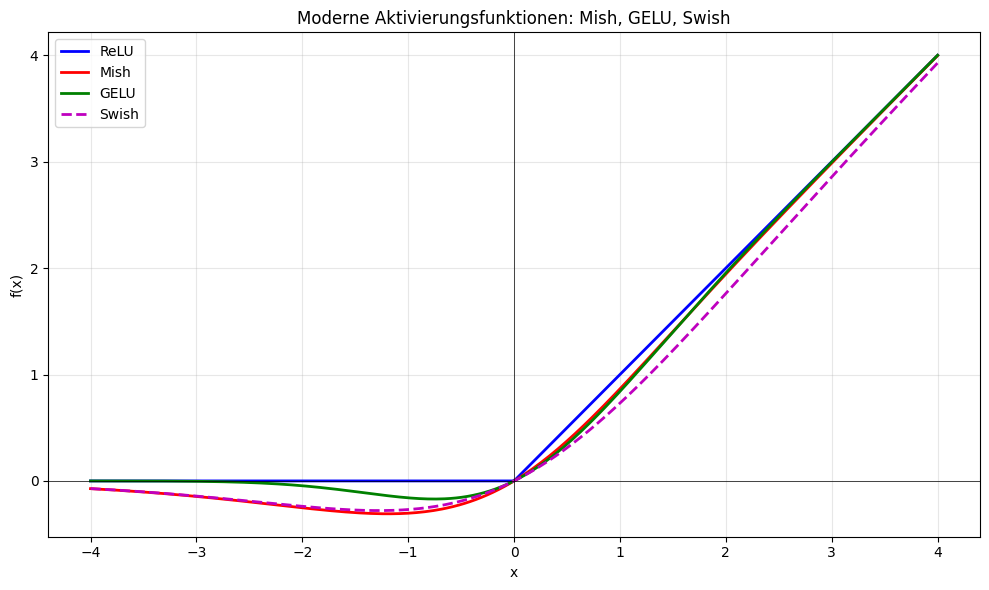

Mish und GELU zeigen oft bessere Performance als ReLU in tiefen Netzen.



Mish-Modell erfolgreich erstellt!
Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 32)                96        


...

 dense_1 (Dense)             (None, 1)                 33        


Total params: 129


Trainable params: 129


Non-trainable params: 0


_________________________________________________________________


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 4: Aktivierungsfunktionen
# Niveau: Experten
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Implement custom activation functions in TensorFlow
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42); np.random.seed(42)

# Benutzerdefinierte Aktivierungen als Keras-Layer
class Mish(tf.keras.layers.Layer):
    """Mish: x * tanh(softplus(x)) — oft besser als ReLU"""
    def call(self, x):
        return x * tf.math.tanh(tf.math.softplus(x))

class GELU(tf.keras.layers.Layer):
    """Gaussian Error Linear Unit — verwendet in BERT, GPT"""
    def call(self, x):
        return 0.5 * x * (1.0 + tf.math.tanh(
            tf.cast(tf.sqrt(2.0/np.pi), tf.float32) * (x + 0.044715 * tf.pow(x, 3))))

class PReLU_custom(tf.keras.layers.Layer):
    """Parametric ReLU — lernbarer negativer Slope"""
    def build(self, input_shape):
        self.alpha = self.add_weight(name='alpha', shape=(1,), initializer='zeros', trainable=True)
    def call(self, x):
        return tf.where(x > 0, x, self.alpha * x)

# Numerische Implementierungen für Visualisierung
x_vals = np.linspace(-4, 4, 300).astype(np.float32)

gelu_np  = 0.5 * x_vals * (1 + np.tanh(np.sqrt(2/np.pi) * (x_vals + 0.044715 * x_vals**3)))
mish_np  = x_vals * np.tanh(np.log(1 + np.exp(np.clip(x_vals, -500, 500))))
swish_np = x_vals * (1 / (1 + np.exp(-np.clip(x_vals, -500, 500))))
relu_np  = np.maximum(0, x_vals)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_vals, relu_np,  'b-', linewidth=2, label='ReLU')
ax.plot(x_vals, mish_np,  'r-', linewidth=2, label='Mish')
ax.plot(x_vals, gelu_np,  'g-', linewidth=2, label='GELU')
ax.plot(x_vals, swish_np, 'm--', linewidth=2, label='Swish')
ax.set_title('Moderne Aktivierungsfunktionen: Mish, GELU, Swish')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5); ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()
print("Mish und GELU zeigen oft bessere Performance als ReLU in tiefen Netzen.")

# Beispiel: Mish in einem Keras-Modell
modell_mish = tf.keras.Sequential([
    tf.keras.layers.Dense(32, input_shape=(2,)),
    Mish(),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
modell_mish.compile(optimizer='adam', loss='binary_crossentropy')
print("\nMish-Modell erfolgreich erstellt!")
modell_mish.summary()


## Exercise 2

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `from scipy import stats` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `def informationsgehalt_analyse(aktivierung_fn, ...` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `X = np.random.randn(n_proben)` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `return {` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `def sigmoid(x): return 1/(1+np.exp(-np.clip(x,-...` | Berechnet die Exponentialfunktion (e^x). Dies ist ein wichtiger Baustein für viele Aktivierungsfunktionen wie Sigmoid. |
| `def relu(x): return np.maximum(0, x)` | Gibt für jeden Eintrag den Maximalwert zurück. Wird oft verwendet, um die ReLU-Funktion manuell zu implementieren (Max aus 0 und Wert). |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print("=== Aktivierungsstatistiken ===")` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


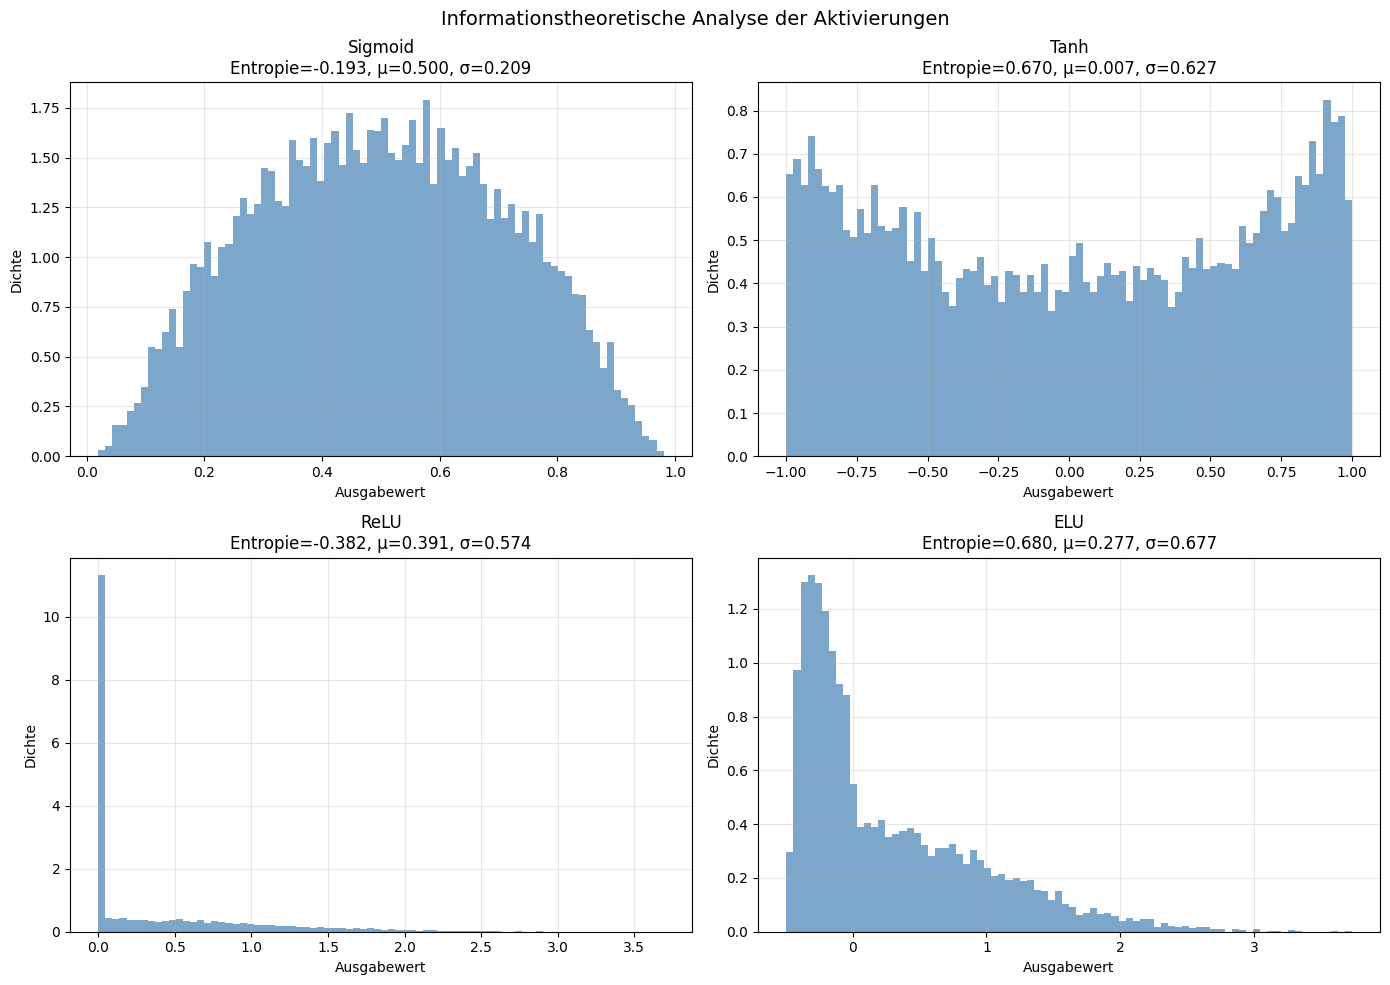

=== Aktivierungsstatistiken ===
Sigmoid   : Entropie=-0.193 | μ=+0.500 | σ=0.209 | Schiefe=+0.003
Tanh      : Entropie=0.670 | μ=+0.007 | σ=0.627 | Schiefe=-0.007
ReLU      : Entropie=-0.382 | μ=+0.391 | σ=0.574 | Schiefe=+1.625
ELU       : Entropie=0.680 | μ=+0.277 | σ=0.677 | Schiefe=+1.224

Gespeichert: informationsgehalt.png


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 4: Aktivierungsfunktionen
# Niveau: Experten
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Explore information-theoretic properties of activation functions
import numpy as np

import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

def informationsgehalt_analyse(aktivierung_fn, name, n_proben=10000):
    """Analysiert statistische Eigenschaften der Aktivierungsausgaben"""
    X = np.random.randn(n_proben)
    ausgaben = aktivierung_fn(X)
    
    # Differentielle Entropie via Histogramm
    hist, bin_edges = np.histogram(ausgaben, bins=50, density=True)
    bin_breite = bin_edges[1] - bin_edges[0]
    hist_pos = hist[hist > 0]
    entropie = -np.sum(hist_pos * np.log(hist_pos + 1e-15) * bin_breite)
    
    return {
        'ausgaben': ausgaben,
        'entropie': entropie,
        'mittelwert': ausgaben.mean(),
        'std': ausgaben.std(),
        'schiefe': stats.skew(ausgaben)
    }

# Aktivierungsfunktionen definieren
def sigmoid(x): return 1/(1+np.exp(-np.clip(x,-500,500)))
def relu(x): return np.maximum(0, x)
def elu(x): return np.where(x > 0, x, 0.5*(np.exp(np.clip(x,-500,0))-1))

funktionen = {
    'Sigmoid': sigmoid,
    'Tanh':    np.tanh,
    'ReLU':    relu,
    'ELU':     elu
}

analysen = {name: informationsgehalt_analyse(fn, name) for name, fn in funktionen.items()}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Informationstheoretische Analyse der Aktivierungen', fontsize=14)

for ax, (name, data) in zip(axes.flatten(), analysen.items()):
    ax.hist(data['ausgaben'], bins=80, alpha=0.7, color='steelblue', density=True, edgecolor='none')
    ax.set_title(f'{name}\nEntropie={data["entropie"]:.3f}, μ={data["mittelwert"]:.3f}, σ={data["std"]:.3f}')
    ax.set_xlabel('Ausgabewert'); ax.set_ylabel('Dichte')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== Aktivierungsstatistiken ===")
for name, data in analysen.items():
    print(f"{name:10s}: Entropie={data['entropie']:.3f} | "
          f"μ={data['mittelwert']:+.3f} | σ={data['std']:.3f} | "
          f"Schiefe={data['schiefe']:+.3f}")
print("\nGespeichert: informationsgehalt.png")


## Exercise 3

**Dataset Used:** Synthetic Classification Data (sklearn.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import make_classification` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X, y = make_classification(n_samples=2000, n_fe...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `def erstelle_modell(aktivierung, mit_batchnorm):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `schichten = [tf.keras.layers.Dense(128, input_s...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `if mit_batchnorm:` | Eine Wenn-Dann-Bedingung. Der Code danach wird nur ausgeführt, wenn diese Bedingung wahr ist. |
| `schichten.append(tf.keras.layers.BatchNormaliza...` | Fügt eine Schicht hinzu, die die Daten normalisiert (zentriert und skaliert), damit das Modell schneller und stabiler lernt. |
| `for _ in range(3):` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `m.compile(optimizer='adam', loss='binary_crosse...` | Wählt Adam als Optimierer aus. Adam ist ein sehr intelligenter Algorithmus, der die Lernrate für jedes Gewicht automatisch anpasst. |
| `return m` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `print(f"{key:20s}: finale Testgenauigkeit = {h....` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


relu                : finale Testgenauigkeit = 92.00%


relu + BN           : finale Testgenauigkeit = 92.75%


sigmoid             : finale Testgenauigkeit = 82.50%


sigmoid + BN        : finale Testgenauigkeit = 90.50%


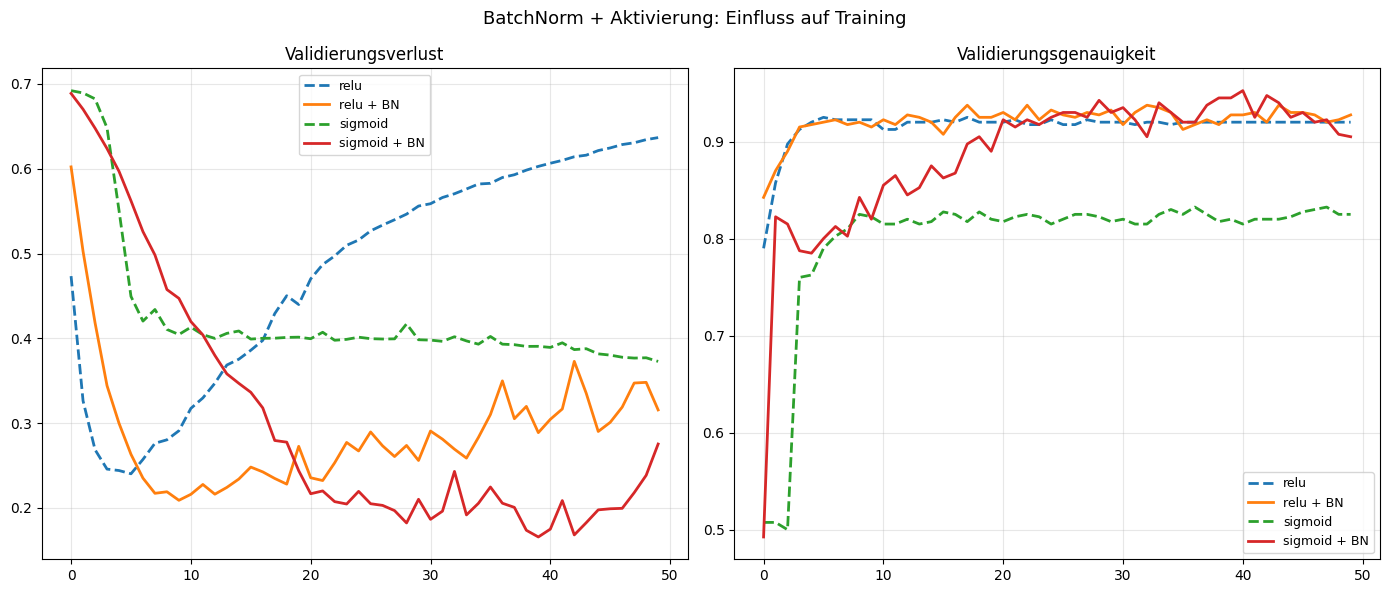

In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 4: Aktivierungsfunktionen
# Niveau: Experten
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Analyze effect of Batch Normalization combined with different activations
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42); np.random.seed(42)

X, y = make_classification(n_samples=2000, n_features=20, n_informative=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)

def erstelle_modell(aktivierung, mit_batchnorm):
    """Modell mit optionaler BatchNormalization"""
    schichten = [tf.keras.layers.Dense(128, input_shape=(X_train.shape[1],))]
    if mit_batchnorm:
        schichten.append(tf.keras.layers.BatchNormalization())
    schichten.append(tf.keras.layers.Activation(aktivierung))
    
    for _ in range(3):
        schichten.append(tf.keras.layers.Dense(64))
        if mit_batchnorm:
            schichten.append(tf.keras.layers.BatchNormalization())
        schichten.append(tf.keras.layers.Activation(aktivierung))
    
    schichten.append(tf.keras.layers.Dense(1, activation='sigmoid'))
    m = tf.keras.Sequential(schichten)
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

ergebnisse = {}
for akt in ['relu', 'sigmoid']:
    for bn in [False, True]:
        key = f"{akt} + BN" if bn else akt
        tf.random.set_seed(42)
        m = erstelle_modell(akt, bn)
        h = m.fit(X_train, y_train, validation_data=(X_test, y_test),
                  epochs=50, batch_size=64, verbose=0)
        ergebnisse[key] = h.history
        print(f"{key:20s}: finale Testgenauigkeit = {h.history['val_accuracy'][-1]:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for key, hist in ergebnisse.items():
    stil = '-' if 'BN' in key else '--'
    axes[0].plot(hist['val_loss'], label=key, linestyle=stil, linewidth=2)
    axes[1].plot(hist['val_accuracy'], label=key, linestyle=stil, linewidth=2)

for ax, titel in zip(axes, ['Validierungsverlust', 'Validierungsgenauigkeit']):
    ax.set_title(titel); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle('BatchNorm + Aktivierung: Einfluss auf Training', fontsize=13)
plt.tight_layout()
plt.show()
